In [ ]:
from fairlearn.reductions import ExponentiatedGradient, EqualizedOdds, DemographicParity
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
import random

In [112]:
os.makedirs("report/images", exist_ok=True)
random.seed(42)
np.random.seed(42)

In [113]:
df = pd.read_csv("./datasets/compas-scores-two-years.csv")
df

,id,name,first,last,compas_screening_date,sex,dob,age,age_cat,race,...,v_decile_score,v_score_text,v_screening_date,in_custody,out_custody,priors_count.1,start,end,event,two_year_recid
0,1,miguel hernandez,miguel,hernandez,2013-08-14,Male,1947-04-18,69,Greater than 45,Other,...,1,Low,2013-08-14,2014-07-07,2014-07-14,0,0,327,0,0
1,3,kevon dixon,kevon,dixon,2013-01-27,Male,1982-01-22,34,25 - 45,African-American,...,1,Low,2013-01-27,2013-01-26,2013-02-05,0,9,159,1,1
2,4,ed philo,ed,philo,2013-04-14,Male,1991-05-14,24,Less than 25,African-American,...,3,Low,2013-04-14,2013-06-16,2013-06-16,4,0,63,0,1
3,5,marcu brown,marcu,brown,2013-01-13,Male,1993-01-21,23,Less than 25,African-American,...,6,Medium,2013-01-13,NaN,NaN,1,0,1174,0,0
4,6,bouthy pierrelouis,bouthy,pierrelouis,2013-03-26,Male,1973-01-22,43,25 - 45,Other,...,1,Low,2013-03-26,NaN,NaN,2,0,1102,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7209,10996,steven butler,steven,butler,2013-11-23,Male,1992-07-17,23,Less than 25,African-American,...,5,Medium,2013-11-23,2013-11-22,2013-11-24,0,1,860,0,0
7210,10997,malcolm simmons,malcolm,simmons,2014-02-01,Male,1993-03-25,23,Less than 25,African-American,...,5,Medium,2014-02-01,2014-01-31,2014-02-02,0,1,790,0,0
7211,10999,winston gregory,winston,gregory,2014-01-14,Male,1958-10-01,57,Greater than 45,Other,...,1,Low,2014-01-14,2014-01-13,2014-01-14,0,0,808,0,0
7212,11000,farrah jean,farrah,jean,2014-03-09,Female,1982-11-17,33,25 - 45,African-American,...,2,Low,2014-03-09,2014-03-08,2014-03-09,3,0,754,0,0


In [114]:
# ProPublica filters (got from chatgpt)
df = df[
    (df.days_b_screening_arrest.between(-30, 30))
    & (df.is_recid != -1)
    & (df.age >= 18)
    & (df.race.isin(["African-American", "Caucasian"]))
    & (df.decile_score.notna())
]
df.dropna(inplace=True, axis=1)
df

,id,name,first,last,compas_screening_date,sex,dob,age,age_cat,race,...,v_decile_score,v_score_text,v_screening_date,in_custody,out_custody,priors_count.1,start,end,event,two_year_recid
1,3,kevon dixon,kevon,dixon,2013-01-27,Male,1982-01-22,34,25 - 45,African-American,...,1,Low,2013-01-27,2013-01-26,2013-02-05,0,9,159,1,1
2,4,ed philo,ed,philo,2013-04-14,Male,1991-05-14,24,Less than 25,African-American,...,3,Low,2013-04-14,2013-06-16,2013-06-16,4,0,63,0,1
6,8,edward riddle,edward,riddle,2014-02-19,Male,1974-07-23,41,25 - 45,Caucasian,...,2,Low,2014-02-19,2014-03-31,2014-04-18,14,5,40,1,1
8,10,elizabeth thieme,elizabeth,thieme,2014-03-16,Female,1976-06-03,39,25 - 45,Caucasian,...,1,Low,2014-03-16,2014-03-15,2014-03-18,0,2,747,0,0
10,14,benjamin franc,benjamin,franc,2013-11-26,Male,1988-06-01,27,25 - 45,Caucasian,...,4,Low,2013-11-26,2013-11-25,2013-11-26,0,0,857,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7207,10994,jarred payne,jarred,payne,2014-05-10,Male,1985-07-31,30,25 - 45,African-American,...,2,Low,2014-05-10,2015-10-22,2015-10-22,0,0,529,1,1
7208,10995,raheem smith,raheem,smith,2013-10-20,Male,1995-06-28,20,Less than 25,African-American,...,9,High,2013-10-20,2014-04-07,2014-04-27,0,0,169,0,0
7209,10996,steven butler,steven,butler,2013-11-23,Male,1992-07-17,23,Less than 25,African-American,...,5,Medium,2013-11-23,2013-11-22,2013-11-24,0,1,860,0,0
7210,10997,malcolm simmons,malcolm,simmons,2014-02-01,Male,1993-03-25,23,Less than 25,African-American,...,5,Medium,2014-02-01,2014-01-31,2014-02-02,0,1,790,0,0


In [115]:
counts = []
for col in df.columns:
    counts.append((len(df[col].unique()), col))
counts.sort()
counts.reverse()
counts

[(5278, 'id'),
 (5278, 'c_jail_in'),
 (5278, 'c_case_number'),
 (5268, 'c_jail_out'),
 (5241, 'name'),
 (4265, 'dob'),
 (3017, 'last'),
 (2165, 'first'),
 (1080, 'out_custody'),
 (1066, 'in_custody'),
 (1066, 'end'),
 (677, 'v_screening_date'),
 (677, 'screening_date'),
 (677, 'compas_screening_date'),
 (221, 'start'),
 (142, 'c_days_from_compas'),
 (62, 'age'),
 (56, 'days_b_screening_arrest'),
 (36, 'priors_count.1'),
 (36, 'priors_count'),
 (10, 'v_decile_score'),
 (10, 'juv_misd_count'),
 (10, 'decile_score.1'),
 (10, 'decile_score'),
 (9, 'juv_fel_count'),
 (8, 'juv_other_count'),
 (3, 'v_score_text'),
 (3, 'score_text'),
 (3, 'age_cat'),
 (2, 'two_year_recid'),
 (2, 'sex'),
 (2, 'race'),
 (2, 'is_violent_recid'),
 (2, 'is_recid'),
 (2, 'event'),
 (2, 'c_charge_degree'),
 (1, 'v_type_of_assessment'),
 (1, 'type_of_assessment')]

In [116]:
# this wasn't in the question, but it makes sense else the model will be too slow and also may overfit
for count, col in counts:
    if count > 100:
        df = df.drop(columns=[col])

In [137]:
ans = df.groupby("race").agg({"two_year_recid": "mean"})
print(ans.to_latex())
ans

\begin{tabular}{lr}
\toprule
 & two_year_recid \\
race &  \\
\midrule
African-American & 0.523150 \\
Caucasian & 0.390870 \\
\bottomrule
\end{tabular}



,two_year_recid
race,
African-American,0.52315
Caucasian,0.39087


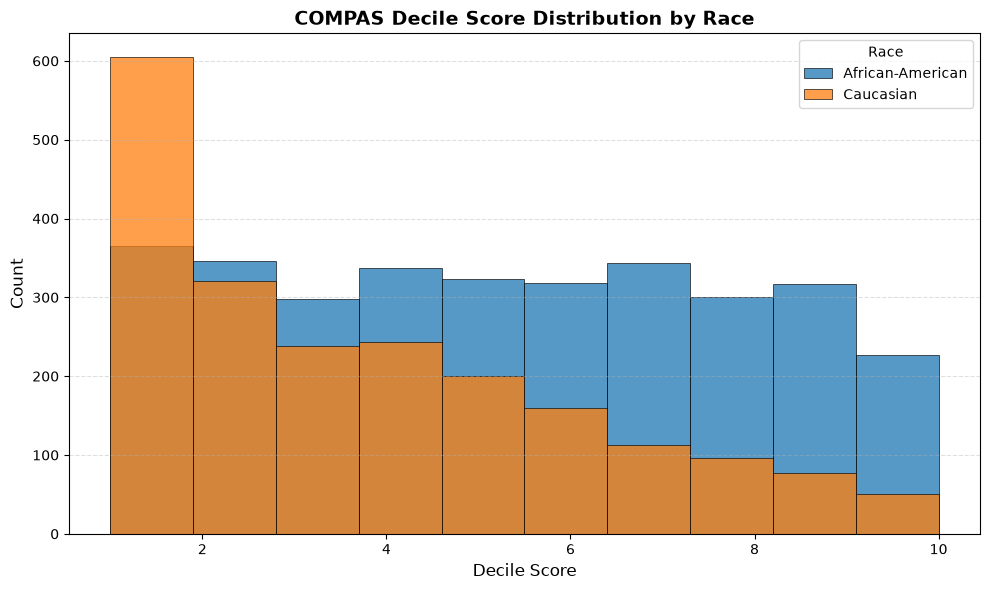

In [118]:
races = df["race"].unique()


palette = plt.cm.Set2(np.linspace(0, 1, len(races)))
fig, ax = plt.subplots(figsize=(10, 6))

for race in races:
    scores = df[df["race"] == race]["decile_score"]
    ax.hist(scores, bins=10, alpha=0.75, label=race, edgecolor="black", linewidth=0.6)

ax.set_xlabel("Decile Score", fontsize=12)
ax.set_ylabel("Count", fontsize=12)
ax.set_title("COMPAS Decile Score Distribution by Race", fontsize=14, fontweight="bold")
ax.legend(title="Race")
ax.grid(axis="y", alpha=0.4, linestyle="--")
fig.tight_layout()
fig.savefig("report/images/compas_decile_score_distribution_by_race.png", dpi=150)


In [119]:
def get_data(df, target_col):
    target = df[target_col]
    X = df.drop(columns=[target_col])
    X = pd.get_dummies(X, drop_first=True)
    data = pd.concat([X, target], axis=1).dropna()

    X = data.drop(columns=[target_col])
    y = data[target_col]

    return train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


def train_logistic_regression(X, y):

    clf = Pipeline(
        [
            ("scaler", StandardScaler()),
            ("logreg", LogisticRegression(max_iter=1000, random_state=42, n_jobs=-1)),
        ]
    )

    clf.fit(X, y)

    return clf


def evaluate_logistic_regression(clf, X, y):
    y_pred = clf.predict(X)
    acc = accuracy_score(y, y_pred)
    report = classification_report(y, y_pred, zero_division=0)
    return acc, report


X_train, X_test, y_train, y_test = get_data(df, "race")
clf = train_logistic_regression(X_train, y_train)
acc, report = evaluate_logistic_regression(clf, X_test, y_test)

print(f"Proxy accuracy: {acc:.3f}")
print(report)

Proxy accuracy: 0.671
                  precision    recall  f1-score   support

African-American       0.69      0.83      0.75       635
       Caucasian       0.62      0.44      0.52       421

        accuracy                           0.67      1056
       macro avg       0.66      0.63      0.63      1056
    weighted avg       0.66      0.67      0.66      1056



/Users/morteza/w/univercity/TrustworthyAI/HW4/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1457: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


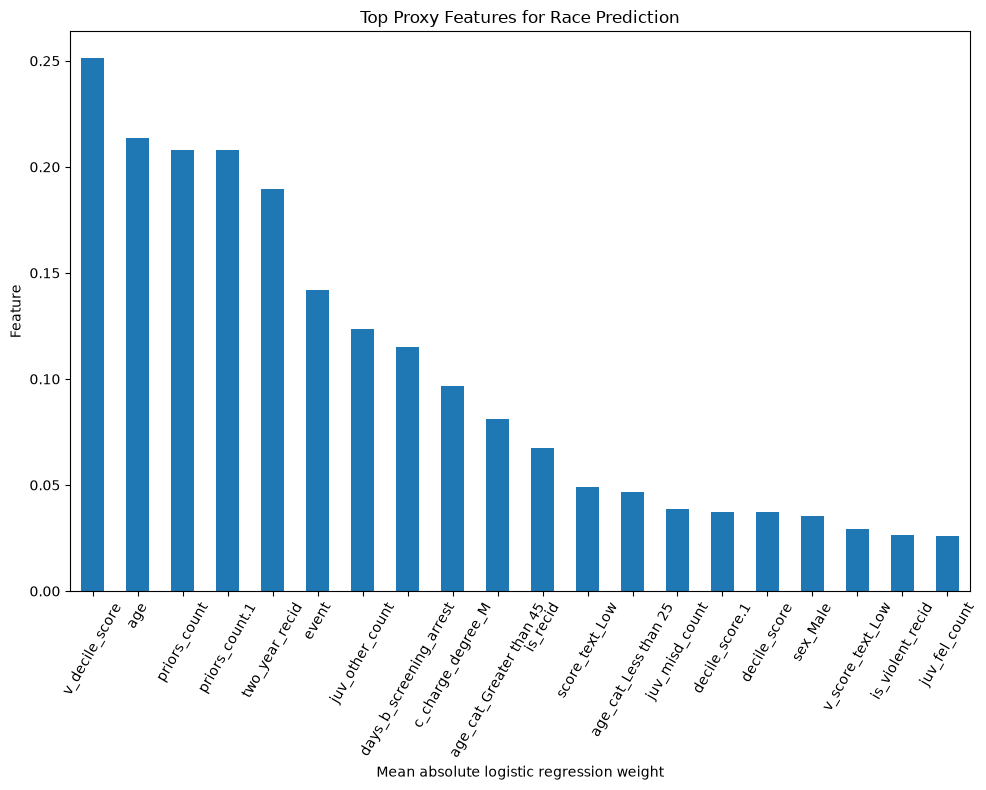

In [120]:
coef_df = pd.DataFrame(
    clf["logreg"].coef_,
    columns=X_train.columns,
)

importance = coef_df.abs().mean(axis=0)
importance = importance.sort_values(ascending=False)
top_features = importance.head(20)

plt.figure(figsize=(10, 8))
top_features.sort_values(ascending=False).plot(kind="bar")
plt.xticks(rotation=60)

plt.xlabel("Mean absolute logistic regression weight")
plt.ylabel("Feature")
plt.title("Top Proxy Features for Race Prediction")

plt.tight_layout()
plt.savefig("report/images/top_proxy_features_for_race_prediction.png", dpi=150)


# Stage 2

In [121]:
X_train, X_test, y_train, y_test = get_data(df, "two_year_recid")
clf = train_logistic_regression(X_train, y_train)
acc, report = evaluate_logistic_regression(clf, X_test, y_test)
print(acc)
print(report)

0.9696969696969697
              precision    recall  f1-score   support

           0       1.00      0.94      0.97       559
           1       0.94      1.00      0.97       497

    accuracy                           0.97      1056
   macro avg       0.97      0.97      0.97      1056
weighted avg       0.97      0.97      0.97      1056



/Users/morteza/w/univercity/TrustworthyAI/HW4/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1457: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


ROC-AUC: 0.980


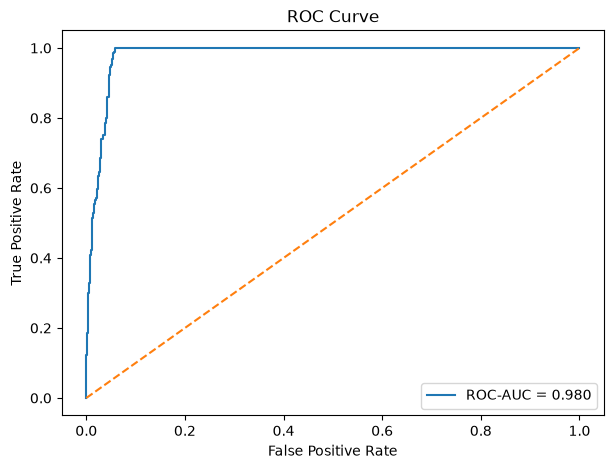

In [122]:
y_prob = clf.predict_proba(X_test)[:, 1]
auc = roc_auc_score(y_test, y_prob)
print(f"ROC-AUC: {auc:.3f}")
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f"ROC-AUC = {auc:.3f}")

plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.savefig("report/images/roc_curve.png", dpi=150)


In [123]:




def group_fairness_metrics(y_true, y_predicted, groups):
    rows = []
    for group in sorted(groups.unique()):
        mask = groups == group
        actual = np.asarray(y_true[mask], dtype=int)
        predicted = np.asarray(y_predicted[mask], dtype=int)

        tp = np.sum((actual == 1) & (predicted == 1))
        fp = np.sum((actual == 0) & (predicted == 1))
        tn = np.sum((actual == 0) & (predicted == 0))
        fn = np.sum((actual == 1) & (predicted == 0))


        rows.append(
            {
                "group": group,
                "acceptance_rate": (tp + fp) / (tp + fp + tn + fn),
                "TPR": (tp) / (tp + fn),
                "FPR": (fp) / (fp + tn),
                "PPV": (tp)/ (tp + fp),
            }
        )

    by_group = pd.DataFrame(rows).set_index("group")
    calc_diff = lambda col: by_group[col].max() - by_group[col].min()

    disparities = pd.Series(
        {
            "Demographic parity": calc_diff("acceptance_rate"),
            "Equal opportunity": calc_diff("TPR"),
            "False positive rate parity difference (FPR gap)": by_group["FPR"].max()
            - by_group["FPR"].min(),
            "PPV difference": by_group["PPV"].max() - by_group["PPV"].min(),
        },
        name="between_group_gap",
    )
    return by_group, disparities


y_pred = clf.predict(X_test)
group_test = df.loc[X_test.index, "race"]
fairness_by_group, fairness_disparities = group_fairness_metrics(
    y_test, y_pred, group_test
)
display(fairness_by_group.round(3))
display(fairness_disparities.round(3).to_frame())

,acceptance_rate,TPR,FPR,PPV
group,,,,
African-American,0.558,1.0,0.077,0.934
Caucasian,0.417,1.0,0.035,0.950


,between_group_gap
Demographic parity,0.141
Equal opportunity,0.000
False positive rate parity difference (FPR gap),0.042
PPV difference,0.015


# Stage 3

In [124]:
X_train, X_test, y_train, y_test = get_data(df.drop('race', axis = 1), "two_year_recid")
clf = train_logistic_regression(X_train, y_train)
acc, report = evaluate_logistic_regression(clf, X_test, y_test)
print("Acc", acc)
print(report)

y_prob = clf.predict_proba(X_test)[:, 1]
auc = roc_auc_score(y_test, y_prob)
print(f"ROC-AUC: {auc:.3f}")

y_pred = clf.predict(X_test)
group_test = df.loc[X_test.index, "race"]
fairness_by_group, fairness_disparities = group_fairness_metrics(
    y_test, y_pred, group_test
)
display(fairness_by_group.round(3))
display(fairness_disparities.round(3).to_frame())

Acc 0.9696969696969697
              precision    recall  f1-score   support

           0       1.00      0.94      0.97       559
           1       0.94      1.00      0.97       497

    accuracy                           0.97      1056
   macro avg       0.97      0.97      0.97      1056
weighted avg       0.97      0.97      0.97      1056

ROC-AUC: 0.980


/Users/morteza/w/univercity/TrustworthyAI/HW4/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1457: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


,acceptance_rate,TPR,FPR,PPV
group,,,,
African-American,0.558,1.0,0.077,0.934
Caucasian,0.417,1.0,0.035,0.950


,between_group_gap
Demographic parity,0.141
Equal opportunity,0.000
False positive rate parity difference (FPR gap),0.042
PPV difference,0.015


# Stage 4

In [125]:
# حذف تاثیر نامناسب
def disparate_impact_remover(
X1, X2, repair_level = 1, quantile_step = 0.25):
    sorted_X1 = np.sort(X1)
    sorted_X2 = np.sort(X2)
    map_X1 = {}
    map_X2 = {}
    for q in np.arange(quantile_step, 1 + quantile_step, quantile_step):
        q1 = np.quantile(X1, q)
        q2 = np.quantile(X2, q)
        avg_q = (q1 + q2) / 2

        range_x1 = sorted_X1[sorted_X1 <= q1]
        range_x2 = sorted_X2[sorted_X2 <= q2]
        for x1 in range_x1:
            map_X1[x1] = x1 + repair_level * (avg_q - x1)
        for x2 in range_x2:
            map_X2[x2] = x2 + repair_level * (avg_q - x2)
        sorted_X1 = sorted_X1[sorted_X1 > q1]
        sorted_X2 = sorted_X2[sorted_X2 > q2]


    repaired_X1 = np.array([map_X1.get(x, x) for x in X1])
    repaired_X2 = np.array([map_X2.get(x, x) for x in X2])
    return repaired_X1, repaired_X2
preprocessed_df = df.copy()
races = df["race"].unique()
assert len(races) == 2
for col in preprocessed_df.columns:
    if col == "race" or col == "two_year_recid":
        continue
    if preprocessed_df[col].dtype in [np.float64, np.int64]:
        preprocessed_df[col] = preprocessed_df[col].astype(float)
        filter1 = preprocessed_df["race"] == races[0]
        filter2 = preprocessed_df["race"] == races[1]
        group1 = preprocessed_df.loc[filter1, col].values
        group2 = preprocessed_df.loc[filter2, col].values
        repaired_group1, repaired_group2 = disparate_impact_remover(group1, group2, repair_level=1)
        preprocessed_df.loc[filter1, col] = repaired_group1
        preprocessed_df.loc[filter2, col] = repaired_group2

X_train, X_test, y_train, y_test = get_data(preprocessed_df.drop('race', axis = 1), "two_year_recid")
clf = train_logistic_regression(X_train, y_train)
acc, report = evaluate_logistic_regression(clf, X_test, y_test)
print("Acc", acc)
print(report)

y_prob = clf.predict_proba(X_test)[:, 1]
auc = roc_auc_score(y_test, y_prob)
print(f"ROC-AUC: {auc:.3f}")

y_pred = clf.predict(X_test)
group_test = preprocessed_df.loc[X_test.index, "race"]
fairness_by_group, fairness_disparities = group_fairness_metrics(
    y_test, y_pred, group_test
)
display(fairness_by_group.round(3))
display(fairness_disparities.round(3).to_frame())


Acc 0.9630681818181818
              precision    recall  f1-score   support

           0       0.98      0.95      0.96       559
           1       0.94      0.98      0.96       497

    accuracy                           0.96      1056
   macro avg       0.96      0.96      0.96      1056
weighted avg       0.96      0.96      0.96      1056

ROC-AUC: 0.977


/Users/morteza/w/univercity/TrustworthyAI/HW4/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1457: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


,acceptance_rate,TPR,FPR,PPV
group,,,,
African-American,0.541,0.972,0.070,0.938
Caucasian,0.417,1.000,0.035,0.950


,between_group_gap
Demographic parity,0.123
Equal opportunity,0.028
False positive rate parity difference (FPR gap),0.035
PPV difference,0.012


In [126]:
# Exp grad

X_train, X_test, y_train, y_test = get_data(df.drop('race', axis = 1), "two_year_recid")

scaler = StandardScaler()
clf = ExponentiatedGradient(
    estimator=LogisticRegression(max_iter=1000, random_state=42),
    constraints=DemographicParity(),
    # constraints=EqualizedOdds(),
)
clf.fit(scaler.fit_transform(X_train), y_train, sensitive_features=df.loc[X_train.index, "race"])
clf = Pipeline(
    [
        ("scaler", scaler),
        ("logreg", clf),
    ]
)

acc, report = evaluate_logistic_regression(clf, X_test, y_test)
print("Acc", acc)
print(report)

y_prob = clf.predict(X_test)
auc = roc_auc_score(y_test, y_prob)
print(f"ROC-AUC: {auc:.3f}")

y_pred = clf.predict(X_test)
group_test = preprocessed_df.loc[X_test.index, "race"]
fairness_by_group, fairness_disparities = group_fairness_metrics(
    y_test, y_pred, group_test
)
display(fairness_by_group.round(3))
display(fairness_disparities.round(3).to_frame())


Acc 0.8797348484848485
              precision    recall  f1-score   support

           0       0.91      0.86      0.88       559
           1       0.85      0.91      0.88       497

    accuracy                           0.88      1056
   macro avg       0.88      0.88      0.88      1056
weighted avg       0.88      0.88      0.88      1056

ROC-AUC: 0.883


,acceptance_rate,TPR,FPR,PPV
group,,,,
African-American,0.506,0.865,0.113,0.893
Caucasian,0.478,0.959,0.162,0.795


,between_group_gap
Demographic parity,0.028
Equal opportunity,0.093
False positive rate parity difference (FPR gap),0.049
PPV difference,0.098


# Stage 5

/Users/morteza/w/univercity/TrustworthyAI/HW4/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1457: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


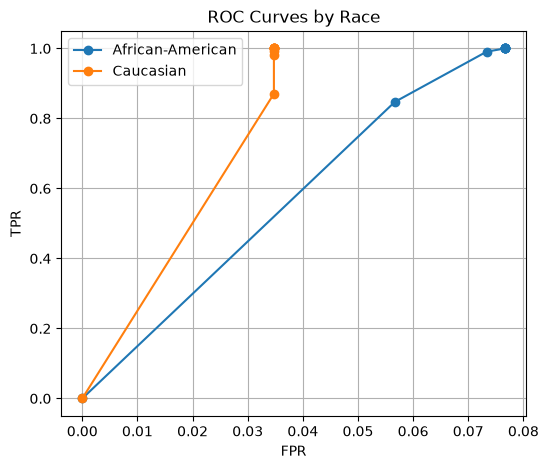

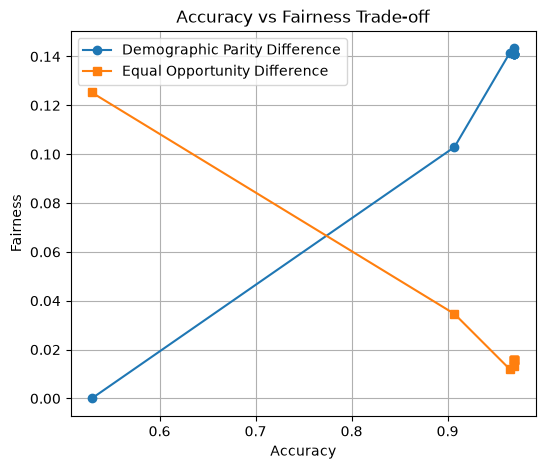

In [138]:

X_train, X_test, y_train, y_test = get_data(df.drop('race', axis = 1), "two_year_recid")
clf = train_logistic_regression(X_train, y_train)
y_prob = clf.predict_proba(X_test)[:, 1]

plot_lines = {}
accuracy_list = []
dp_diff_list = []
error_diff_list = []
thresholds = np.linspace(0.1, 1.0, 10)

for threshold in thresholds:
    preds = (y_prob >= threshold).astype(int)

    # Accuracy
    accuracy_list.append(accuracy_score(y_test, preds))

    positive_rates = []
    error_rates = []

    # ROC points and positive prediction rates
    for race in races:
        race_mask = preprocessed_df.loc[X_test.index, "race"] == race
        race_y_test = y_test[race_mask]
        race_preds = preds[race_mask]

        tpr = np.sum((race_y_test == 1) & (race_preds == 1)) / np.sum(race_y_test == 1)
        fpr = np.sum((race_y_test == 0) & (race_preds == 1)) / np.sum(race_y_test == 0)

        if race not in plot_lines:
            plot_lines[race] = {"tpr": [], "fpr": []}

        plot_lines[race]["tpr"].append(tpr)
        plot_lines[race]["fpr"].append(fpr)

        error_rate = np.sum(race_y_test != race_preds) / len(race_y_test)
        error_rates.append(error_rate)

        positive_rates.append(race_preds.mean())

    # Demographic Parity Difference
    dp_diff_list.append(max(positive_rates) - min(positive_rates))
    error_diff_list.append(max(error_rates) - min(error_rates))


plt.figure(figsize=(6, 5))
for race in races:
    plt.plot(plot_lines[race]["fpr"], plot_lines[race]["tpr"], marker="o", label=race)

plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("ROC Curves by Race")
plt.legend()
plt.grid(True)
plt.savefig("report/images/roc_curves_by_race.png", dpi=150)

plt.figure(figsize=(6, 5))
plt.plot(accuracy_list, dp_diff_list, marker="o", label="Demographic Parity Difference")
plt.plot(accuracy_list, error_diff_list, marker="s", label="Equal Opportunity Difference")


plt.ylabel("Fairness")
plt.xlabel("Accuracy")
plt.title("Accuracy vs Fairness Trade-off")
plt.legend()
plt.grid(True)
plt.savefig("report/images/accuracy_vs_fairness_tradeoff.png", dpi=150)

In [140]:
thresholds = np.linspace(0.1, 0.9, 9)


rows = []

for threshold in thresholds:
    preds = (y_prob >= threshold).astype(int)

    for race in races:
        mask = preprocessed_df.loc[X_test.index, "race"] == race

        y_true = y_test[mask].to_numpy()
        y_pred = preds[mask]

        TP = np.sum((y_true == 1) & (y_pred == 1))
        FP = np.sum((y_true == 0) & (y_pred == 1))
        TN = np.sum((y_true == 0) & (y_pred == 0))
        FN = np.sum((y_true == 1) & (y_pred == 0))

        pi = np.mean(y_true)

        PPV = TP / (TP + FP) if TP + FP > 0 else np.nan
        FNR = FN / (FN + TP) if FN + TP > 0 else np.nan
        FPR = FP / (FP + TN) if FP + TN > 0 else np.nan

        FPR_identity = (pi / (1 - pi)) * ((1 - PPV) / PPV) * (1 - FNR)

        rows.append({
            "threshold": threshold,
            "race": race,
            "base_rate": pi,
            "PPV": PPV,
            "FNR": FNR,
            "FPR": FPR,
            "FPR_identity": FPR_identity,
            "difference": FPR - FPR_identity ,
        })

results = pd.DataFrame(rows)
print(results["difference"].abs().max())

5.551115123125783e-17


# Stage 6

In [129]:

X_train, X_test, y_train, y_test = get_data(df.drop('race', axis = 1), "two_year_recid")

scaler = StandardScaler()
clf = ExponentiatedGradient(
    estimator=LogisticRegression(max_iter=1000, random_state=42),
    constraints=DemographicParity(),
)
clf.fit(scaler.fit_transform(X_train), y_train, sensitive_features=df.loc[X_train.index, "race"])
clf = Pipeline(
    [
        ("scaler", scaler),
        ("logreg", clf),
    ]
)

y_pred = clf.predict(X_test)
df["race-sex"] = df["race"].astype(str) + "-" + df["sex"].astype(str)

for col in ("race", "sex", "race-sex"):
    print("Column:", col)
    _, fairness_disparities = group_fairness_metrics(
        y_test, y_pred,
        df.loc[X_test.index,col]
    )
    display(fairness_disparities.round(3).to_frame())


Column: race


,between_group_gap
Demographic parity,0.046
Equal opportunity,0.075
False positive rate parity difference (FPR gap),0.031
PPV difference,0.083


Column: sex


,between_group_gap
Demographic parity,0.031
Equal opportunity,0.061
False positive rate parity difference (FPR gap),0.044
PPV difference,0.094


Column: race-sex


,between_group_gap
Demographic parity,0.066
Equal opportunity,0.109
False positive rate parity difference (FPR gap),0.089
PPV difference,0.174
